<a href="https://colab.research.google.com/github/peihphmcok/ML_Best-Football-Team/blob/main/ML2_Final_DataProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload dữ liệu => Xử lí mising value => Chuẩn + mã hóa numerical và categorical column => PCA => Diagram (barchart về overall của position của dataset cần xem xét thêm)

PCA:

Missing values:
 short_name                         0
player_positions                   0
overall                            0
potential                          0
value_eur                         89
wage_eur                          78
Unnamed: 6                     18533
nationality_name                   0
preferred_foot                     0
pace                            2063
shooting                        2063
passing                         2063
defending                       2063
skill_ball_control                 0
skill_long_passing                 0
mentality_penalties                0
movement_balance                   0
power_stamina                      0
attacking_crossing                 0
attacking_finishing                0
attacking_heading_accuracy         0
attacking_short_passing            0
defending_marking_awareness        0
defending_standing_tackle          0
defending_sliding_tackle           0
goalkeeping_diving                 0
goalkeeping_handling 

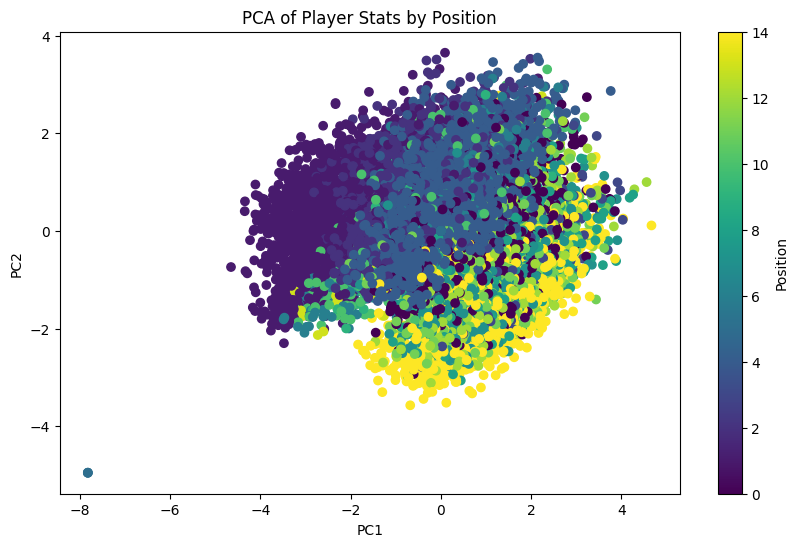

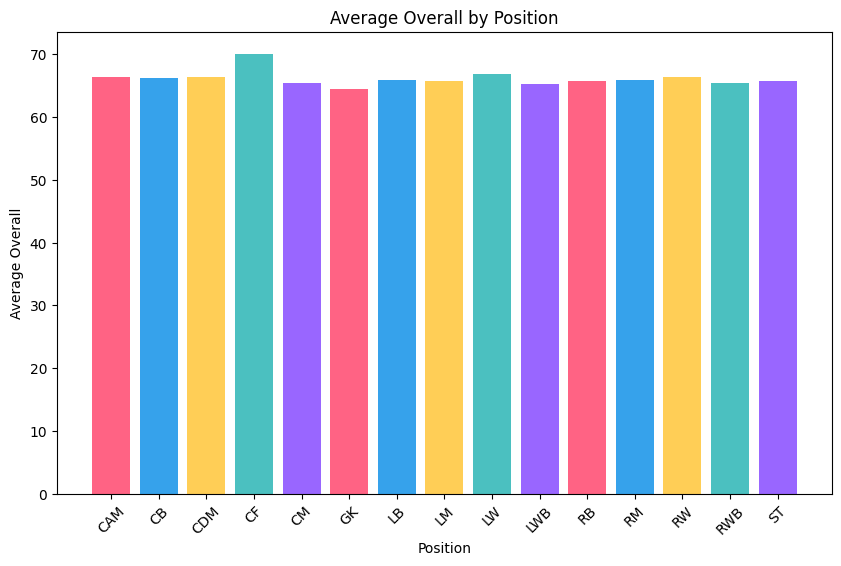

Processed data saved to 'processed_players_with_pca.csv'
       short_name player_positions  overall  potential  value_eur  wage_eur  \
0        L. Messi               RW       91         91       54.0     195.0   
1      K. Benzema           CF, ST       91         91       64.0     450.0   
2  R. Lewandowski               ST       91         91       84.0     420.0   
3    K. De Bruyne          CM, CAM       91         91      107.5     350.0   
4      K. MbappÃ©           ST, LW       91         95      190.5     230.0   

   Unnamed: 6 nationality_name preferred_foot      pace  ...  \
0         NaN        Argentina           Left  1.226679  ...   
1         NaN           France          Right  1.129936  ...   
2         NaN           Poland          Right  0.646224  ...   
3         NaN          Belgium          Right  0.549482  ...   
4         NaN           France          Right  2.774557  ...   

   goalkeeping_handling  goalkeeping_kicking  goalkeeping_positioning  \
0         

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Tạo DataFrame rỗng với các cột dựa trên dữ liệu mẫu
df = pd.read_csv('/content/drive/MyDrive/ML2_Lab_Data/Final/dataset_9.6.csv')

# 2. Gán địa chỉ file CSV (bạn thay 'your_data.csv' bằng đường dẫn thực tế)
# Ví dụ: df = pd.read_csv('path/to/your/data.csv')
# Bạn có thể thêm df sau dòng này khi có file
# df = pd.read_csv('your_data.csv')

# 3. Kiểm tra và làm sạch dữ liệu cơ bản
numerical_columns = ['pace',
                     'shooting',
                     'passing',
                     'defending',
                     'skill_ball_control',
                     'skill_long_passing',
                     'mentality_penalties',
                     'movement_balance',
                     'power_stamina',
                     'attacking_crossing',
                     'attacking_finishing',
                     'attacking_heading_accuracy',
                     'attacking_short_passing',
                     'defending_marking_awareness',
                     'defending_standing_tackle',
                     'defending_sliding_tackle',
                     'goalkeeping_diving',
                     'goalkeeping_handling',
                     'goalkeeping_kicking',
                     'goalkeeping_positioning',
                     'goalkeeping_reflexes']
print("Missing values:\n", df.isnull().sum())  # Kiểm tra giá trị thiếu
# df = df.dropna()  # Loại bỏ hàng thiếu (nếu có)
# Thay bằng cái j đó (avrage, median,...)
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].mean())

## Kiểm tra outliers (giả sử kiểm tra value_eur)
#Q1 = df['value_eur'].quantile(0.25)
#Q3 = df['value_eur'].quantile(0.75)
#IQR = Q3 - Q1
#df = df[~((df['value_eur'] < (Q1 - 1.5 * IQR)) | (df['value_eur'] > (Q3 + 1.5 * IQR)))]

# 4. Chuẩn hóa và mã hóa dữ liệu
# Chuẩn hóa giá trị và lương
df['value_eur'] = df['value_eur'] / 1000000  # Chuyển thành triệu euro
df['wage_eur'] = df['wage_eur'] / 1000  # Chuyển thành nghìn euro

# Mã hóa vị trí
def split_positions(pos):
    return pos.split(', ')[0]  # Lấy vị trí chính
df['main_position'] = df['player_positions'].apply(split_positions)

# Mã hóa chân thuận
df['is_left'] = df['preferred_foot'].apply(lambda x: 1 if x == 'Left' else 0)

# 5. Chuẩn hóa số liệu
stats = ['pace', 'shooting', 'passing', 'defending']
scaler = StandardScaler()
df[stats] = scaler.fit_transform(df[stats])

# 6. Tạo đặc trưng mới
df['overall_potential_diff'] = df['potential'] - df['overall']
df['value_per_overall'] = df['value_eur'] / df['overall']

## ___ NO NEED __ Lọc theo ngân sách (giả sử 1000 triệu euro để phù hợp với dữ liệu)
# df = df[df['value_eur'] <= 1000]  # Giới hạn 1000 triệu euro

# 7. Áp dụng PCA
X = df[stats]  # Lấy các chỉ số để giảm chiều
pca = PCA(n_components=2)  # Chọn 2 thành phần chính
X_pca = pca.fit_transform(X)

# Thêm kết quả PCA vào DataFrame
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# In tỷ lệ phương sai giải thích
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# 8. Tạo biểu đồ trực quan hóa
# Scatter plot cho PCA
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['main_position'].astype('category').cat.codes, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Player Stats by Position')
plt.colorbar(scatter, label='Position')
plt.show()

### ____ Bar chart cần xem xét thêm ___

# Bar chart cho trung bình overall theo vị trí
avg_overall = df.groupby('main_position')['overall'].mean()
plt.figure(figsize=(10, 6))
plt.bar(avg_overall.index, avg_overall.values, color=['#FF6384', '#36A2EB', '#FFCE56', '#4BC0C0', '#9966FF'])
plt.xlabel('Position')
plt.ylabel('Average Overall')
plt.title('Average Overall by Position')
plt.xticks(rotation=45)
plt.show()
### ___________________________________


# 9. Lưu dữ liệu đã xử lý
df.to_csv('processed_players_with_pca.csv', index=False)
print("Processed data saved to 'processed_players_with_pca.csv'")
print(df.head())

vì overall gần giống nhau nên không effective trong việc / có vai trò lớn trong việc xác định vị trí của ng đó / đánh giá vai trò nhân vật đó
VD: cannot let GK = tiền đạo or ngược lại => cần xác định rõ position

Box plot dùng để xem xét về overall của tất cả data trong dtset, (tự tra cách

1.   Mục danh sách

*   Mục danh sách
*   Mục danh sách


2.   Mục danh sách

đọc) các chấm tròn là điểm bất thường so sánh với overall, phân tích về các chỉ số của các position so sánh vs nhau

<Figure size 1200x600 with 0 Axes>

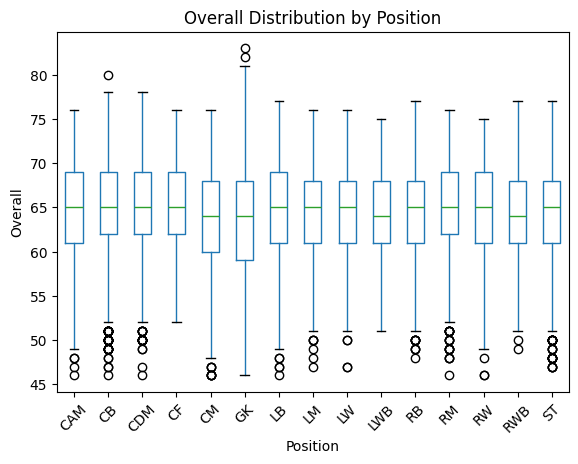

In [ ]:
plt.figure(figsize=(12, 6))
df.boxplot(column='overall', by='main_position', grid=False)
plt.title('Overall Distribution by Position')
plt.suptitle('')
plt.xlabel('Position')
plt.ylabel('Overall')
plt.xticks(rotation=45)
plt.show()

Box :Điểm phổ biến thấp nhất P3 > 25%

Heatmap show corelation giữa các column với nhau

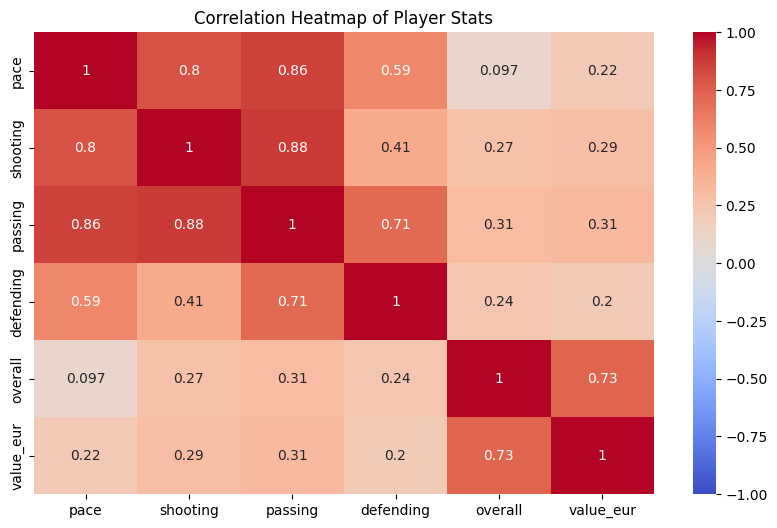

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))
correlation_matrix = df[['pace', 'shooting', 'passing', 'defending', 'overall', 'value_eur']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Player Stats')
plt.show()

Giả sử 1 team đã chọn như bên dưới (sau khi chạy model và output ra = hàm) (có position chia ở 'formation_442' => random chỉ số 'overall' => random số lượng ng mỗi 'position')
=> come up với 1 cái bar chart => phân tích xem output của hàm thường sẽ cho ra team ntn (overall = nhau / overall nhiều hơn ở trước/sau/phòng thủ/ tấn công)

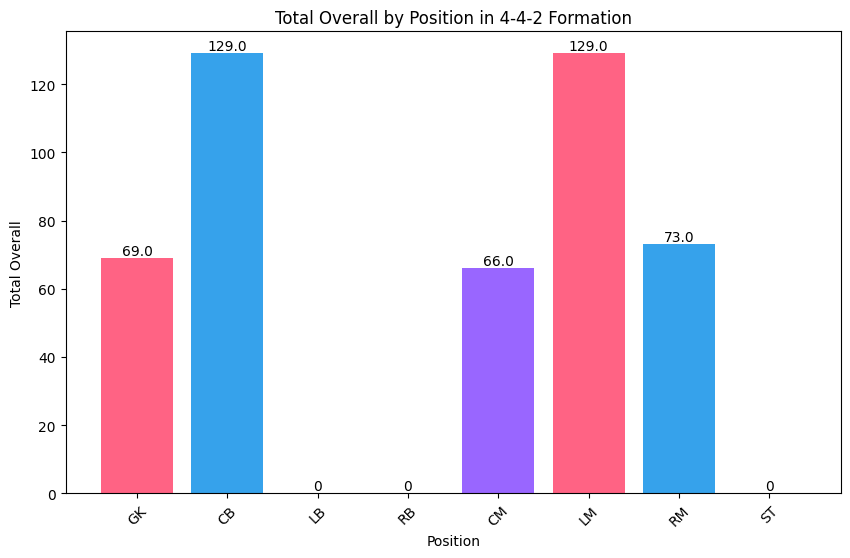

In [ ]:
# Giả sử team là danh sách cầu thủ đã chọn
team = df.sample(n=11, replace=True)  # Thay bằng kết quả từ Knapsack
position_totals = team.groupby('main_position')['overall'].sum()
formation_442 = {'GK': 1, 'CB': 2, 'LB': 1, 'RB': 1, 'CM': 2, 'LM': 1, 'RM': 1, 'ST': 2}
totals = {pos: position_totals.get(pos, 0) for pos in formation_442.keys()}

plt.figure(figsize=(10, 6))
plt.bar(totals.keys(), totals.values(), color=['#FF6384', '#36A2EB', '#FFCE56', '#4BC0C0', '#9966FF'])
plt.xlabel('Position')
plt.ylabel('Total Overall')
plt.title('Total Overall by Position in 4-4-2 Formation')
plt.xticks(rotation=45)
for i, v in enumerate(totals.values()):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()

KHOI

Missing values:
 short_name           1
player_positions     1
overall              1
potential            1
value_eur           90
wage_eur            79
nationality_name     1
preferred_foot       1
pace                 0
shooting             0
passing              0
defending            0
dtype: int64
Explained Variance Ratio: [0.78503033 0.15582271]


<ipython-input-5-0bbfa75e2197>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['value_eur'] = df['value_eur'] / 1000000  # Chuyển thành triệu euro
<ipython-input-5-0bbfa75e2197>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wage_eur'] = df['wage_eur'] / 1000  # Chuyển thành nghìn euro
<ipython-input-5-0bbfa75e2197>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

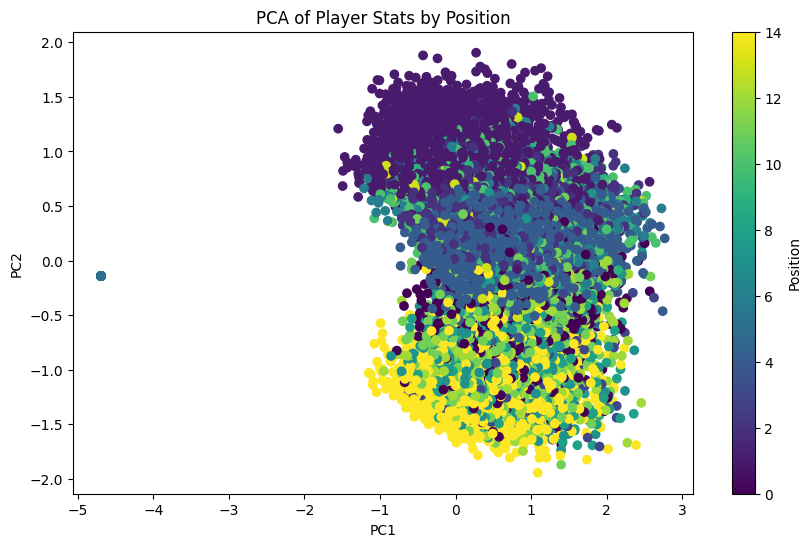

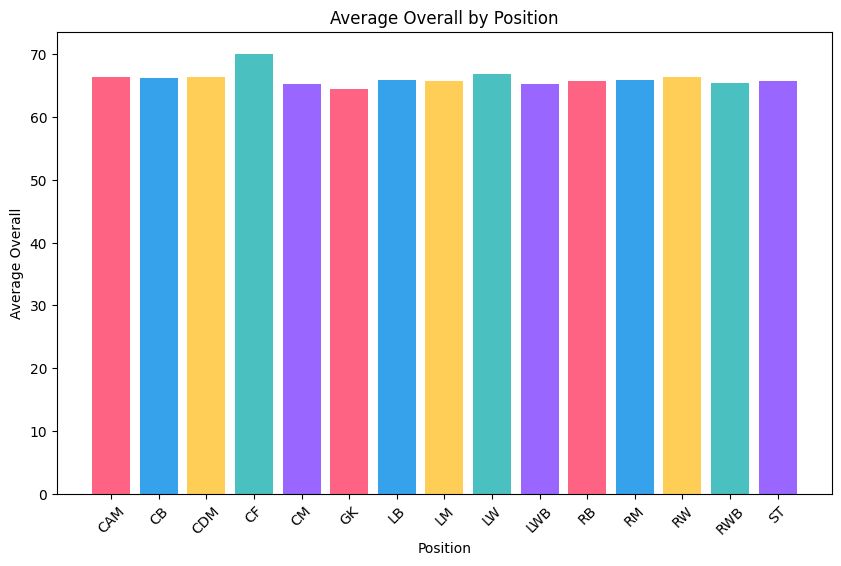

Processed data saved to 'processed_players_with_pca.csv'
       short_name player_positions  overall  potential  value_eur  wage_eur  \
0        L. Messi               RW     91.0       91.0       54.0     195.0   
1      K. Benzema           CF, ST     91.0       91.0       64.0     450.0   
2  R. Lewandowski               ST     91.0       91.0       84.0     420.0   
3    K. De Bruyne          CM, CAM     91.0       91.0      107.5     350.0   
4      K. MbappÃ©           ST, LW     91.0       95.0      190.5     230.0   

  nationality_name preferred_foot      pace  shooting   passing  defending  \
0        Argentina           Left  0.850640  2.005809  1.913761  -0.546958   
1           France          Right  0.808639  1.958298  1.569324  -0.322622   
2           Poland          Right  0.598634  2.100832  1.372504  -0.098287   
3          Belgium          Right  0.556633  1.958298  2.061376   0.799054   
4           France          Right  1.522657  2.005809  1.421709  -0.457223   


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Tạo DataFrame rỗng với các cột dựa trên dữ liệu mẫu
df = pd.read_csv('/content/dataset_ver2 (1).csv')

# 2. Gán địa chỉ file CSV (bạn thay 'your_data.csv' bằng đường dẫn thực tế)
# Ví dụ: df = pd.read_csv('path/to/your/data.csv')
# Bạn có thể thêm df sau dòng này khi có file
# df = pd.read_csv('your_data.csv')

# 3. Kiểm tra và làm sạch dữ liệu cơ bản
print("Missing values:\n", df.isnull().sum())  # Kiểm tra giá trị thiếu
df = df.dropna()  # Loại bỏ hàng thiếu (nếu có)
# df = df.fillna(method='sth') # Thay bằng cái j đó (avrage, median,...)

## Kiểm tra outliers (giả sử kiểm tra value_eur)
#Q1 = df['value_eur'].quantile(0.25)
#Q3 = df['value_eur'].quantile(0.75)
#IQR = Q3 - Q1
#df = df[~((df['value_eur'] < (Q1 - 1.5 * IQR)) | (df['value_eur'] > (Q3 + 1.5 * IQR)))]

# 4. Chuẩn hóa và mã hóa dữ liệu
# Chuẩn hóa giá trị và lương
df['value_eur'] = df['value_eur'] / 1000000  # Chuyển thành triệu euro
df['wage_eur'] = df['wage_eur'] / 1000  # Chuyển thành nghìn euro

# Mã hóa vị trí
def split_positions(pos):
    return pos.split(', ')[0]  # Lấy vị trí chính
df['main_position'] = df['player_positions'].apply(split_positions)

# Mã hóa chân thuận
df['is_left'] = df['preferred_foot'].apply(lambda x: 1 if x == 'Left' else 0)

# 5. Chuẩn hóa số liệu
stats = ['pace', 'shooting', 'passing', 'defending']
scaler = StandardScaler()
df[stats] = scaler.fit_transform(df[stats])

# 6. Tạo đặc trưng mới
df['overall_potential_diff'] = df['potential'] - df['overall']
df['value_per_overall'] = df['value_eur'] / df['overall']

## ___ NO NEED __ Lọc theo ngân sách (giả sử 1000 triệu euro để phù hợp với dữ liệu)
# df = df[df['value_eur'] <= 1000]  # Giới hạn 1000 triệu euro

# 7. Áp dụng PCA
X = df[stats]  # Lấy các chỉ số để giảm chiều
pca = PCA(n_components=2)  # Chọn 2 thành phần chính
X_pca = pca.fit_transform(X)

# Thêm kết quả PCA vào DataFrame
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# In tỷ lệ phương sai giải thích
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# 8. Tạo biểu đồ trực quan hóa
# Scatter plot cho PCA
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['main_position'].astype('category').cat.codes, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Player Stats by Position')
plt.colorbar(scatter, label='Position')
plt.show()

### ____ Bar chart cần xem xét thêm ___

# Bar chart cho trung bình overall theo vị trí
avg_overall = df.groupby('main_position')['overall'].mean()
plt.figure(figsize=(10, 6))
plt.bar(avg_overall.index, avg_overall.values, color=['#FF6384', '#36A2EB', '#FFCE56', '#4BC0C0', '#9966FF'])
plt.xlabel('Position')
plt.ylabel('Average Overall')
plt.title('Average Overall by Position')
plt.xticks(rotation=45)
plt.show()
### ___________________________________


# 9. Lưu dữ liệu đã xử lý
df.to_csv('processed_players_with_pca.csv', index=False)
print("Processed data saved to 'processed_players_with_pca.csv'")
print(df.head())

Missing values:
 short_name             1
player_positions       0
overall                0
potential              0
value_eur              0
wage_eur               0
nationality_name       1
preferred_foot         1
pace                   0
shooting               0
passing                0
defending              0
foot                   0
is_GK                  0
fwd                 2066
mid                 2066
def                 2066
cluster                0
dtype: int64
Explained Variance Ratio: [0.48646393 0.30069686]


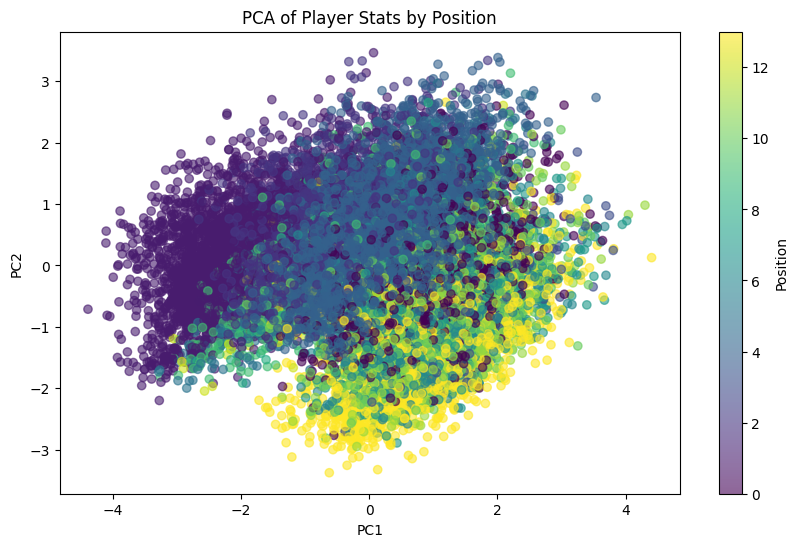

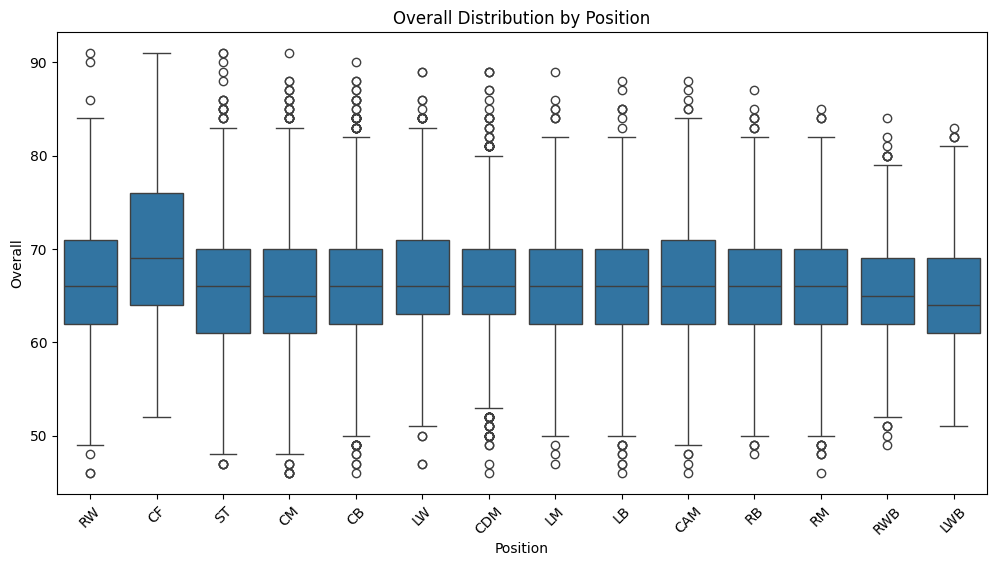

Selected Players in choosed_line_up:
Position: CM
Overall: 87.0
Value (M€): 77.50
Cluster: 0
---
Position: ST
Overall: 82.0
Value (M€): 13.00
Cluster: 1
---
Position: CB
Overall: 82.0
Value (M€): 25.50
Cluster: 2
---
Position: ST
Overall: 82.0
Value (M€): 2.85
Cluster: 3
---
Position: CM
Overall: 91.0
Value (M€): 107.50
Cluster: 4
---
Position: CB
Overall: 88.0
Value (M€): 107.50
Cluster: 5
---
Position: RW
Overall: 91.0
Value (M€): 54.00
Cluster: 6
---
Position: ST
Overall: 77.0
Value (M€): 3.60
Cluster: 7
---
Position: CB
Overall: 82.0
Value (M€): 5.50
Cluster: 8
---
Position: ST
Overall: 84.0
Value (M€): 14.50
Cluster: 9
---


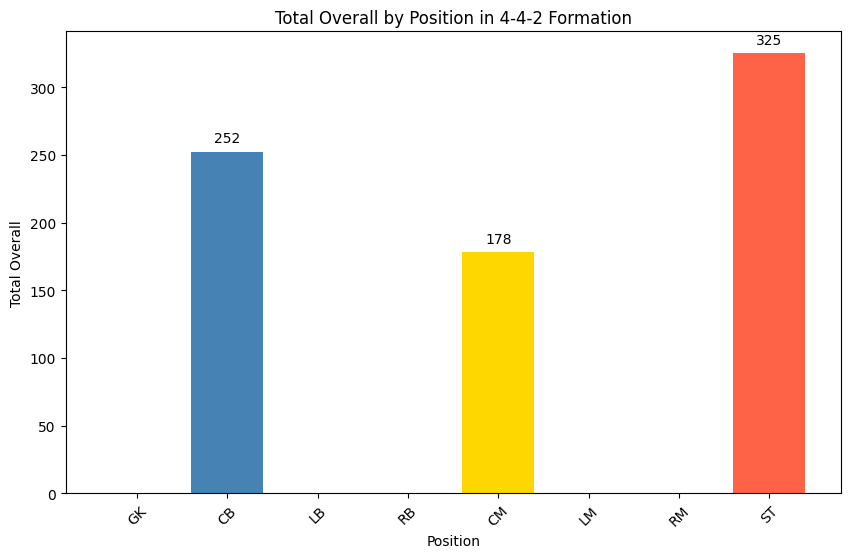

Processed data saved to 'processed_players_with_pca.csv'


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

# Đọc file CSV
df = pd.read_csv('/content/drive/MyDrive/ML2_Lab_Data/Final/dataset_ver2.csv')

# Chuyển đổi cột số và xử lý giá trị thiếu
numerical_cols = ['overall', 'potential', 'value_eur', 'wage_eur', 'pace', 'shooting', 'passing', 'defending']
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df.loc[:, col] = df[col].fillna(df[col].mean())

# Mã hóa preferred_foot
le = LabelEncoder()
df['foot'] = le.fit_transform(df['preferred_foot'])

# Xử lý player_positions
df['player_positions'] = df['player_positions'].fillna('')

# Tạo cột is_GK
df['is_GK'] = df['player_positions'].apply(lambda x: 1 if 'GK' in str(x) else 0)

# Tách dữ liệu GK và non-GK
gk_df = df[df['is_GK'] == 1].copy()
non_gk_df = df[df['is_GK'] == 0].copy()

# Tạo đặc trưng fwd, mid, def
non_gk_df['fwd'] = non_gk_df['pace'] + non_gk_df['shooting']
non_gk_df['mid'] = non_gk_df['passing'] + non_gk_df['pace']
non_gk_df['def'] = non_gk_df['defending']

# Chuẩn hóa và phân cụm
features = ['fwd', 'mid', 'def']
X = non_gk_df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_10 = KMeans(n_clusters=10, random_state=42)
kmeans_10.fit(X_scaled)
labels_10 = kmeans_10.labels_
centers_10 = kmeans_10.cluster_centers_
centers_10_original = scaler.inverse_transform(centers_10)

non_gk_df['cluster'] = labels_10
gk_df['cluster'] = 10

# Kết hợp lại DataFrame
df = pd.concat([non_gk_df, gk_df], ignore_index=True)

# 1. Làm sạch và chuẩn hóa dữ liệu
print("Missing values:\n", df.isnull().sum())
df = df.dropna()

# Chuẩn hóa giá trị và lương
df['value_eur'] = df['value_eur'] / 1000000  # Chuyển thành triệu euro
df['wage_eur'] = df['wage_eur'] / 1000  # Chuyển thành nghìn euro

# Mã hóa vị trí
def split_positions(pos):
    return pos.split(', ')[0] if pos else 'Unknown'
df['main_position'] = df['player_positions'].apply(split_positions)

# Mã hóa chân thuận
df['is_left'] = df['preferred_foot'].apply(lambda x: 1 if x == 'Left' else 0)

# Chuẩn hóa số liệu
stats = ['pace', 'shooting', 'passing', 'defending']
scaler_stats = StandardScaler()
df[stats] = scaler_stats.fit_transform(df[stats])

# Tạo đặc trưng mới
df['overall_potential_diff'] = df['potential'] - df['overall']
df['value_per_overall'] = df['value_eur'] / df['overall']

# Lọc theo ngân sách (giả sử 1000 triệu euro)
df = df[df['value_eur'] <= 1000]

# 2. Áp dụng PCA
X_pca = df[stats]
pca = PCA(n_components=2)
X_pca_transformed = pca.fit_transform(X_pca)

# Thêm kết quả PCA vào DataFrame
df['PC1'] = X_pca_transformed[:, 0]
df['PC2'] = X_pca_transformed[:, 1]

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# 3. Tạo các biểu đồ
# a. Scatter Plot PCA
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['PC1'], df['PC2'], c=df['main_position'].astype('category').cat.codes, cmap='viridis', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Player Stats by Position')
plt.colorbar(scatter, label='Position')
plt.show()

# b. Box Plot cho Overall theo Vị trí
plt.figure(figsize=(12, 6))
sns.boxplot(x='main_position', y='overall', data=df)
plt.title('Overall Distribution by Position')
plt.xlabel('Position')
plt.ylabel('Overall')
plt.xticks(rotation=45)
plt.show()

# c. Hàm lấy cầu thủ có overall cao nhất từ mỗi cluster
def get_top_players_by_cluster(df, n_clusters=11):
    choosed_line_up = []
    formation_442 = {'GK': 1, 'CB': 2, 'LB': 1, 'RB': 1, 'CM': 2, 'LM': 1, 'RM': 1, 'ST': 2}
    for cluster_id in range(n_clusters):
        cluster_data = df[df['cluster'] == cluster_id]
        if not cluster_data.empty:
            top_player = cluster_data.loc[cluster_data['overall'].idxmax()]
            positions = top_player['player_positions'].split(', ')
            main_pos = next((pos for pos in positions if pos in formation_442), positions[0])
            top_player = top_player.copy()
            top_player['main_position'] = main_pos
            choosed_line_up.append(top_player)
    # Đảm bảo đủ số lượng mỗi vị trí
    position_counts = {pos: sum(1 for p in choosed_line_up if p['main_position'] == pos) for pos in formation_442}
    return choosed_line_up

choosed_line_up = get_top_players_by_cluster(df)

# Hiển thị thông tin các cầu thủ
print("Selected Players in choosed_line_up:")
for player in choosed_line_up:
    print(f"Position: {player['main_position']}")
    print(f"Overall: {player['overall']}")
    print(f"Value (M€): {player['value_eur']:.2f}")
    print(f"Cluster: {player['cluster']}")
    print("---")

# d. Bar Chart cho Tổng Overall theo Đội hình 4-4-2
formation_442 = {'GK': 1, 'CB': 2, 'LB': 1, 'RB': 1, 'CM': 2, 'LM': 1, 'RM': 1, 'ST': 2}
position_totals = {pos: sum(p['overall'] for p in choosed_line_up if p['main_position'] == pos) for pos in formation_442}
for pos in formation_442:
    if pos not in position_totals:
        position_totals[pos] = 0

plt.figure(figsize=(10, 6))
bars = plt.bar(position_totals.keys(), position_totals.values(),
               color=['#FF6347' if pos in ['ST'] else '#4682B4' if pos in ['GK', 'CB', 'LB', 'RB'] else '#FFD700' for pos in position_totals.keys()])
plt.title('Total Overall by Position in 4-4-2 Formation')
plt.xlabel('Position')
plt.ylabel('Total Overall')
for bar, total in zip(bars, position_totals.values()):
    if total > 0:
        plt.text(bar.get_x() + bar.get_width()/2, total + 5, str(int(total)), ha='center', va='bottom')
plt.xticks(rotation=45)
plt.show()

# Lưu dữ liệu đã xử lý
df.to_csv('processed_players_with_pca.csv', index=False)
print("Processed data saved to 'processed_players_with_pca.csv'")

KHOI


<ipython-input-2-f7e760f6dbf1>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='position_group', y='overall', data=df, palette='viridis')


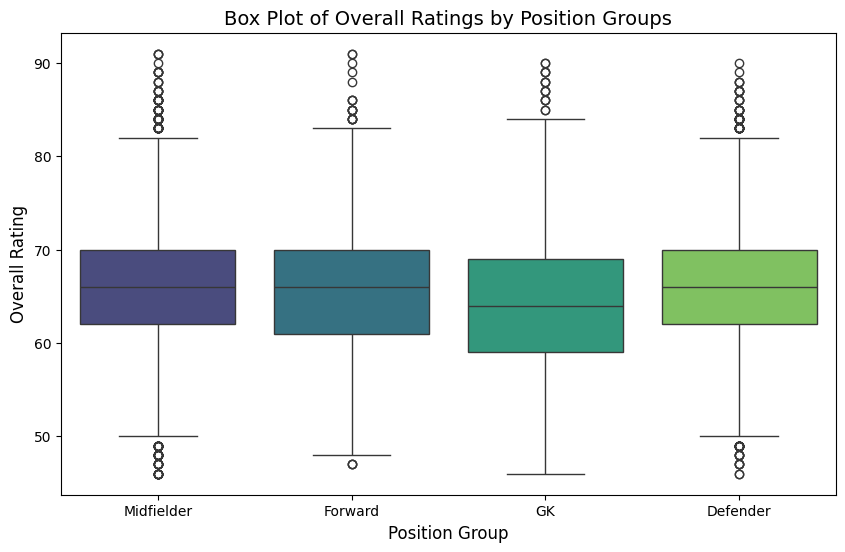

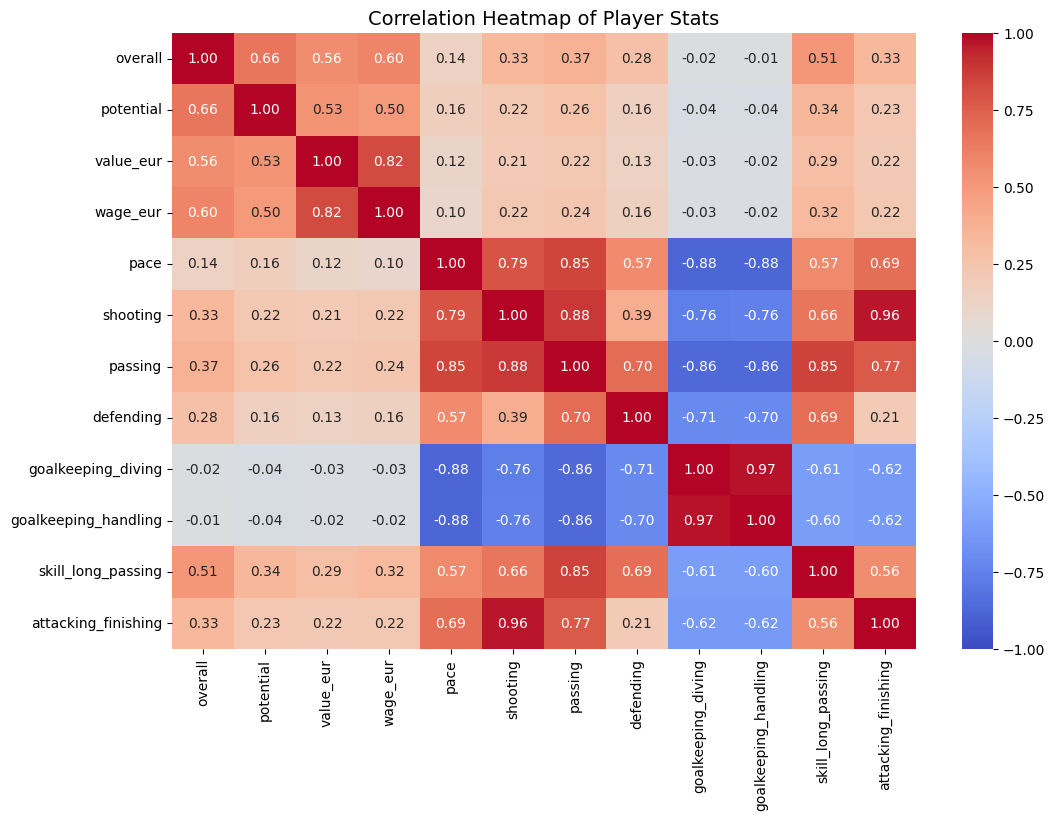

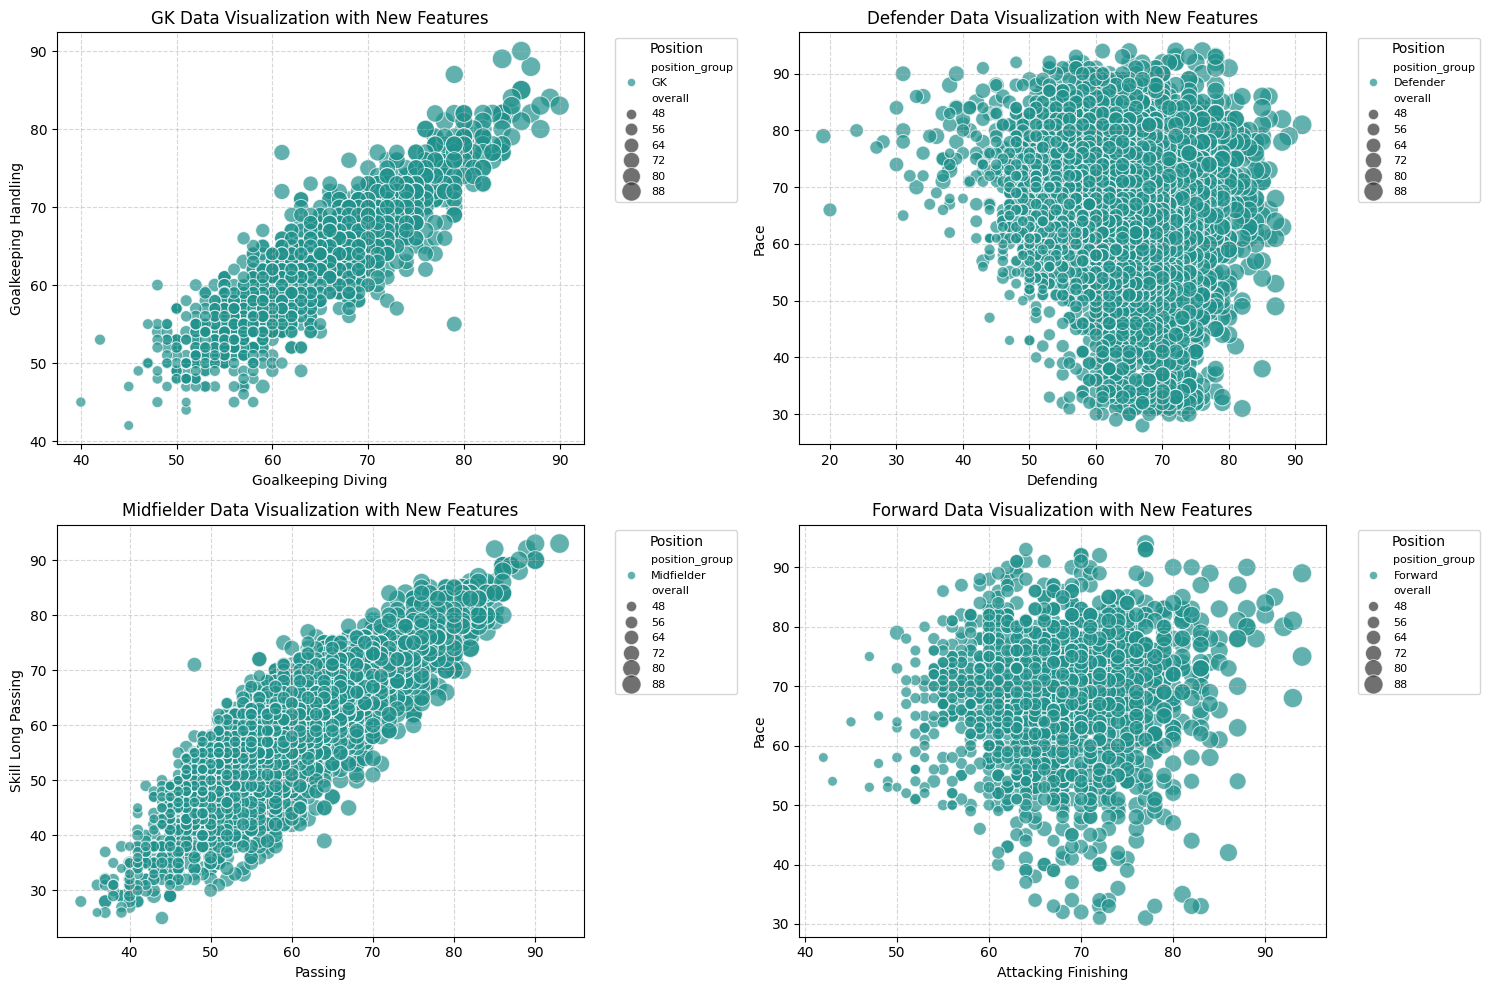

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the dataset
df = pd.read_csv('/dataset_ver2_0906.csv')

# Add the 'position_group' column
# Define a function to map player positions to broader groups
def categorize_position(positions):
    if pd.isna(positions):
        return 'Unknown'
    pos_list = positions.split(', ')
    if 'GK' in pos_list:
        return 'GK'
    elif any(pos in ['CB', 'LB', 'RB', 'LWB', 'RWB'] for pos in pos_list):
        return 'Defender'
    elif any(pos in ['CM', 'CDM', 'CAM', 'LM', 'RM', 'LW', 'RW'] for pos in pos_list):
        return 'Midfielder'
    elif any(pos in ['ST', 'CF'] for pos in pos_list):
        return 'Forward'
    else:
        return 'Other' # Handle positions that don't fit neatly

df['position_group'] = df['player_positions'].apply(categorize_position)

# Box plot cho overall theo nhóm vị trí
plt.figure(figsize=(10, 6))
# Ensure 'position_group' exists before plotting
if 'position_group' in df.columns:
    sns.boxplot(x='position_group', y='overall', data=df, palette='viridis')
    plt.title('Box Plot of Overall Ratings by Position Groups', fontsize=14)
    plt.xlabel('Position Group', fontsize=12)
    plt.ylabel('Overall Rating', fontsize=12)
    plt.savefig('overall_boxplot_new.png')
    plt.show()
else:
    print("Error: 'position_group' column not found after creation attempt.")


# Heatmap tương quan
# Make sure numerical_cols are indeed numeric and handle potential errors
numeric_cols_to_corr = ['overall', 'potential', 'value_eur', 'wage_eur', 'pace',
                  'shooting', 'passing', 'defending', 'goalkeeping_diving',
                  'goalkeeping_handling', 'skill_long_passing', 'attacking_finishing']
# Select only columns present in the DataFrame
numeric_cols_to_corr = [col for col in numeric_cols_to_corr if col in df.columns]

# Convert selected columns to numeric, coercing errors to NaN
for col in numeric_cols_to_corr:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN in the selected columns for correlation calculation,
# or fill them if appropriate for your analysis
# For this example, we'll drop NaNs for correlation calculation
df_corr = df[numeric_cols_to_corr].dropna()

if not df_corr.empty:
    plt.figure(figsize=(12, 8))
    sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
    plt.title('Correlation Heatmap of Player Stats', fontsize=14)
    plt.savefig('correlation_heatmap_new.png')
    plt.show()
else:
    print("Not enough numeric data after cleaning for correlation heatmap.")


# Scatter plot với features mới
plt.figure(figsize=(15, 10))
position_groups_to_plot = ['GK', 'Defender', 'Midfielder', 'Forward']
plot_features = {
    'GK': ('goalkeeping_diving', 'goalkeeping_handling'),
    'Defender': ('defending', 'pace'),
    'Midfielder': ('passing', 'skill_long_passing'),
    'Forward': ('attacking_finishing', 'pace')
}

# Filter DataFrame to include only rows with relevant position groups
df_filtered = df[df['position_group'].isin(position_groups_to_plot)].copy()

# Convert relevant columns to numeric and handle potential errors
for group in position_groups_to_plot:
    x_col, y_col = plot_features[group]
    if x_col not in df_filtered.columns or y_col not in df_filtered.columns:
        print(f"Warning: Columns {x_col} or {y_col} not found for {group} plot. Skipping.")
        continue

    df_filtered.loc[:, x_col] = pd.to_numeric(df_filtered[x_col], errors='coerce')
    df_filtered.loc[:, y_col] = pd.to_numeric(df_filtered[y_col], errors='coerce')
    df_filtered.loc[:, 'overall'] = pd.to_numeric(df_filtered['overall'], errors='coerce')


for i, group in enumerate(position_groups_to_plot, 1):
    plt.subplot(2, 2, i)
    group_df = df_filtered[df_filtered['position_group'] == group].dropna(subset=[plot_features[group][0], plot_features[group][1], 'overall']) # Drop NaNs specific to this plot

    if not group_df.empty:
        x_col, y_col = plot_features[group]
        sns.scatterplot(data=group_df, x=x_col, y=y_col, hue='position_group', size='overall', sizes=(50, 200), palette='viridis', alpha=0.7)
        plt.title(f'{group} Data Visualization with New Features', fontsize=12)
        plt.xlabel(x_col.replace('_', ' ').title(), fontsize=10)
        plt.ylabel(y_col.replace('_', ' ').title(), fontsize=10)
        plt.legend(title='Position', fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.5)
    else:
        print(f"No valid data to plot for {group}.")

plt.tight_layout()
plt.savefig('data_visualization_new.png')
plt.show()

Explained Variance Ratio by Principal Components: [0.5306005  0.22798055]
Total Explained Variance: 0.7585810537874172


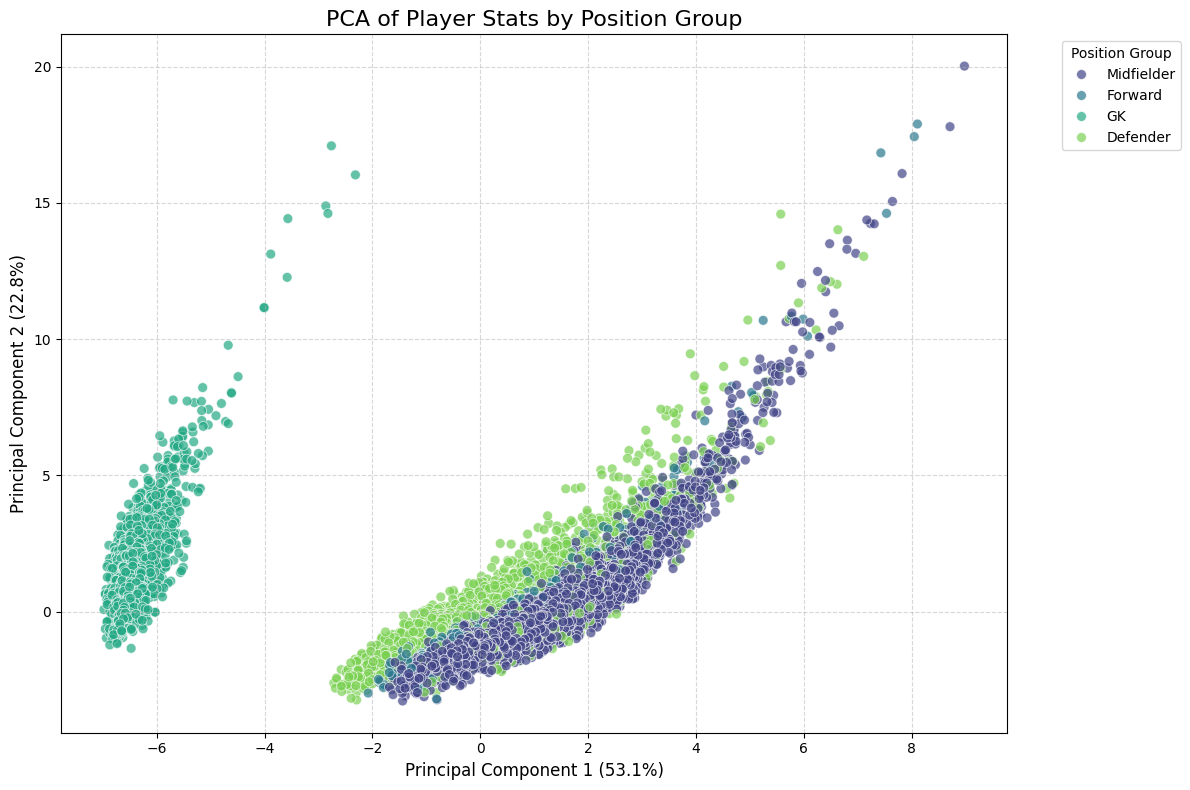

In [ ]:

# ## PCA Visualization
# Áp dụng PCA để giảm chiều dữ liệu và trực quan hóa sự phân bố của các cầu thủ dựa trên các chỉ số, phân biệt màu theo nhóm vị trí.

# %%
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for potentially better plot styling

# Ensure the DataFrame 'df' and 'position_group' exist from previous steps
# If running this cell independently, you would need to load the data and create 'position_group'
# Example (if running standalone):
df = pd.read_csv('/dataset_ver2_0906.csv ')
def categorize_position(positions):
    if pd.isna(positions): return 'Unknown'
    pos_list = positions.split(', ')
    if 'GK' in pos_list: return 'GK'
    elif any(pos in ['CB', 'LB', 'RB', 'LWB', 'RWB'] for pos in pos_list): return 'Defender'
    elif any(pos in ['CM', 'CDM', 'CAM', 'LM', 'RM', 'LW', 'RW'] for pos in pos_list): return 'Midfielder'
    elif any(pos in ['ST', 'CF'] for pos in pos_list): return 'Forward'
    else: return 'Other'
df['position_group'] = df['player_positions'].apply(categorize_position)

# Select numerical features for PCA
# You might want to select relevant numerical columns, excluding IDs, names, etc.
# Use the same numerical columns you used for the heatmap earlier for consistency
pca_features = ['overall', 'potential', 'value_eur', 'wage_eur', 'pace',
                  'shooting', 'passing', 'defending', 'goalkeeping_diving',
                  'goalkeeping_handling', 'skill_long_passing', 'attacking_finishing']

# Filter to only include columns that exist in the DataFrame
pca_features = [col for col in pca_features if col in df.columns]

# Convert selected columns to numeric, coercing errors and filling NaNs (if any remain)
for col in pca_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].mean()) # Fill NaNs with mean, or choose another strategy

# Select the data for PCA and handle any remaining missing values if dropna wasn't sufficient
X = df[pca_features].dropna() # Drop rows with any remaining NaNs in selected features

# Check if there's enough data after dropping NaNs
if X.empty or len(X) < 2:
    print("Not enough data or features available for PCA after cleaning.")
else:
    # Keep track of the index before scaling/PCA to merge results back
    original_index = X.index

    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply PCA
    # We'll start with 2 components for 2D visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # Create a new DataFrame for PCA results
    pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'], index=original_index)

    # Merge PCA results back to the original DataFrame based on index
    # We need the 'position_group' column for coloring
    df_pca_plot = df.loc[original_index].copy() # Use .loc to align with X's index
    df_pca_plot['PC1'] = pca_df['PC1']
    df_pca_plot['PC2'] = pca_df['PC2']

    # In tỷ lệ phương sai giải thích bởi các thành phần chính
    print("Explained Variance Ratio by Principal Components:", pca.explained_variance_ratio_)
    print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

    # Visualize the PCA results
    plt.figure(figsize=(12, 8))

    # Use seaborn's scatterplot for better handling of categorical hues
    sns.scatterplot(
        data=df_pca_plot,
        x='PC1',
        y='PC2',
        hue='position_group', # Color by position group
        palette='viridis',    # Color palette
        s=50,                 # Size of points
        alpha=0.7             # Transparency
    )

    plt.title('PCA of Player Stats by Position Group', fontsize=16)
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title='Position Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

For n_clusters = 2 The average silhouette_score is : 0.7049787496083262
For n_clusters = 3 The average silhouette_score is : 0.5882004012129721
For n_clusters = 4 The average silhouette_score is : 0.6505186632729437
For n_clusters = 5 The average silhouette_score is : 0.561464362648773
For n_clusters = 6 The average silhouette_score is : 0.4857596147013469


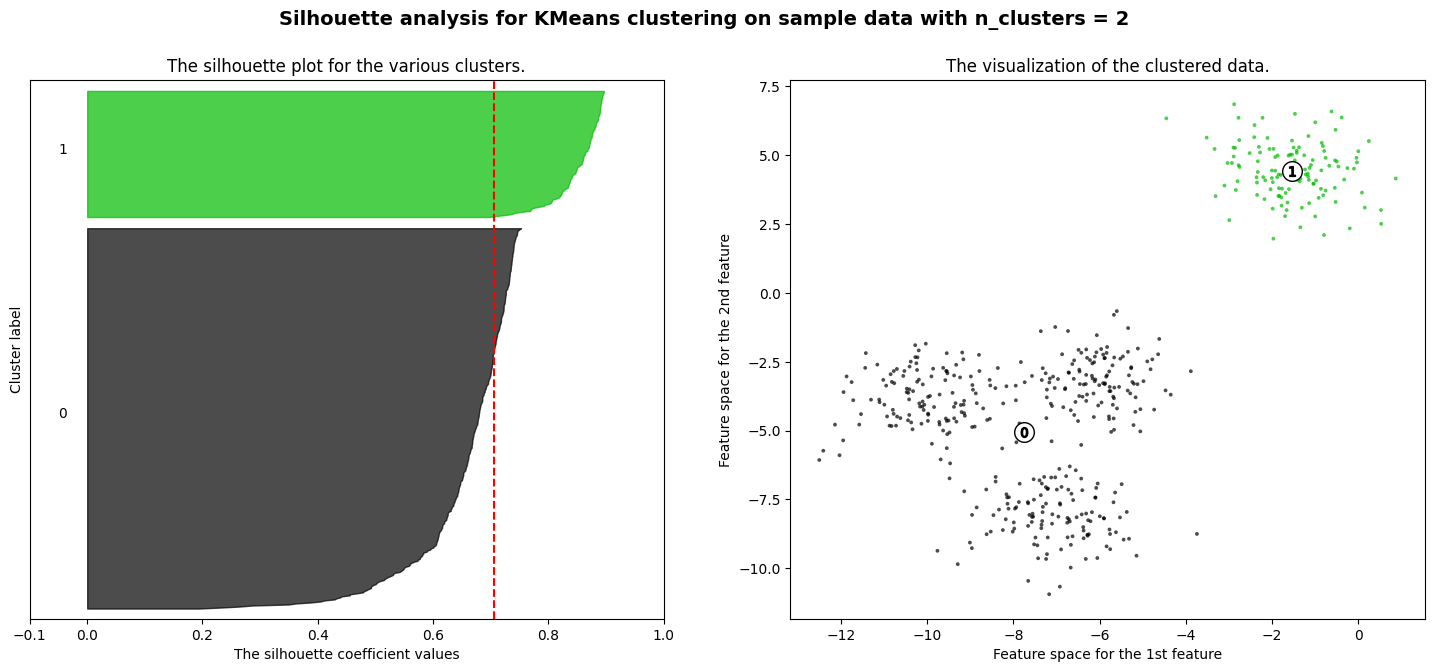

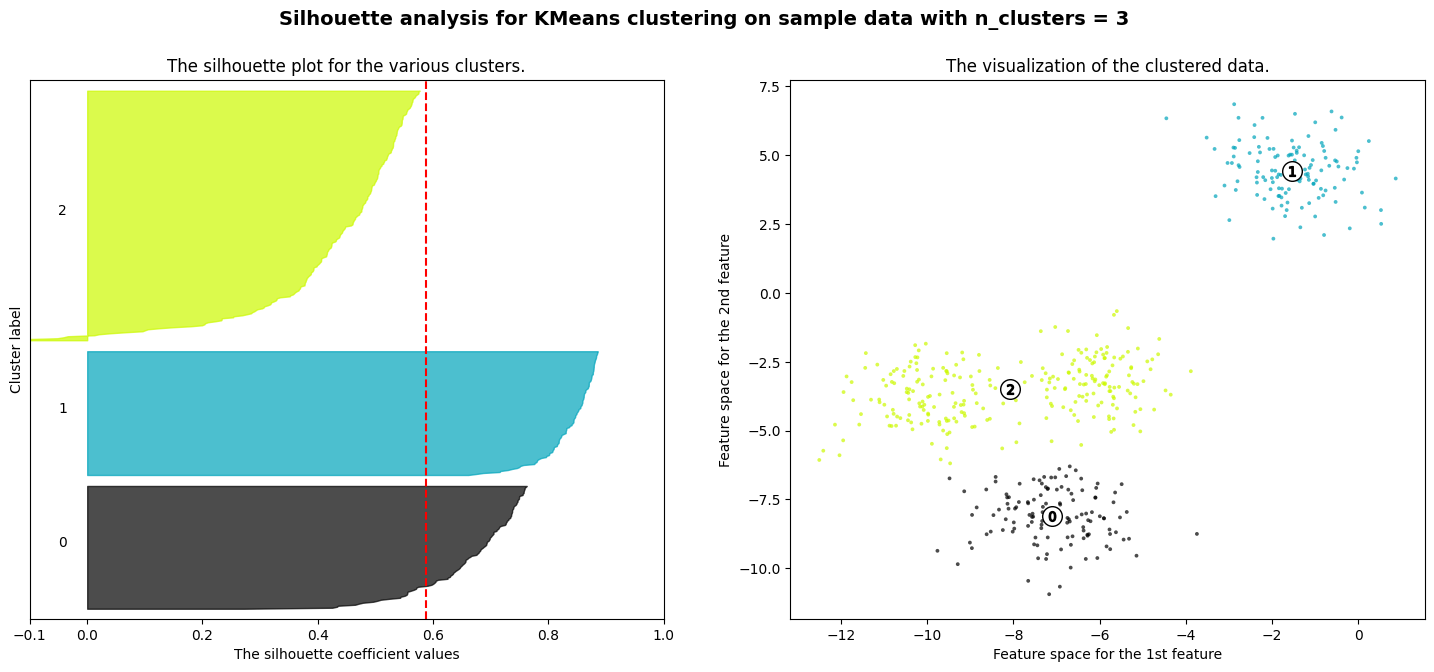

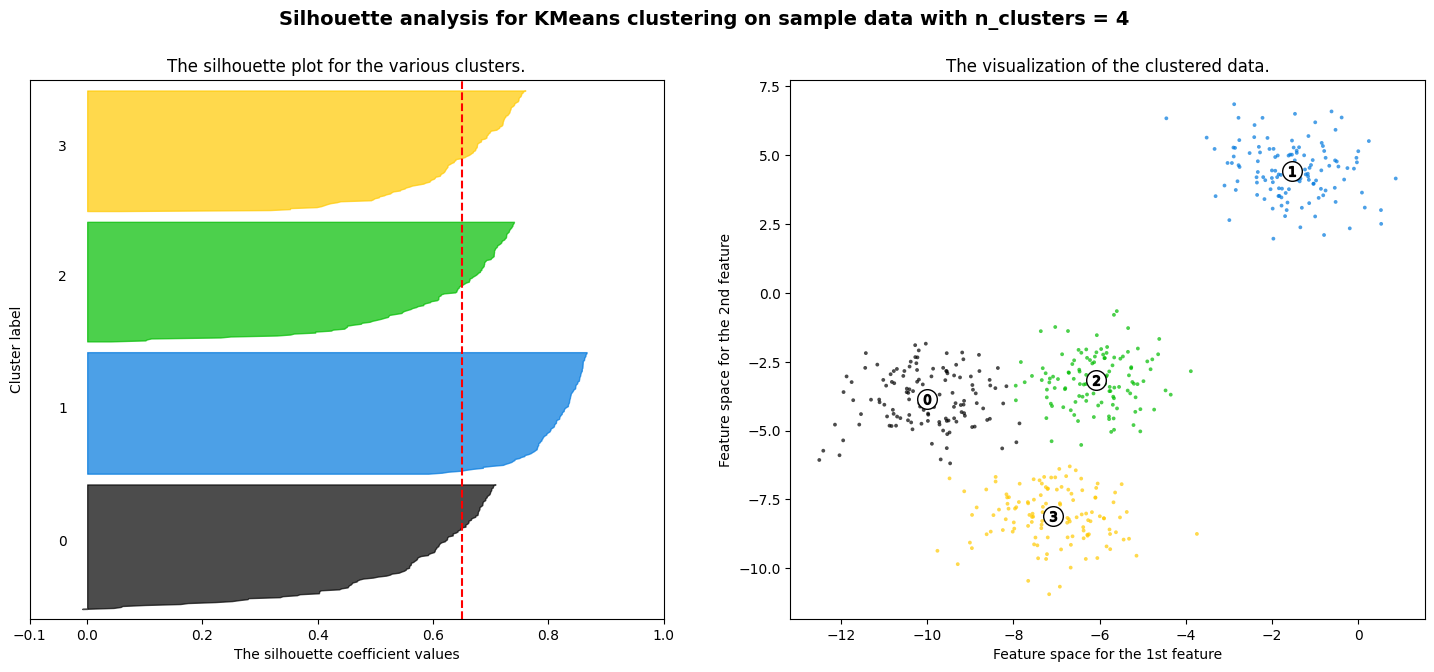

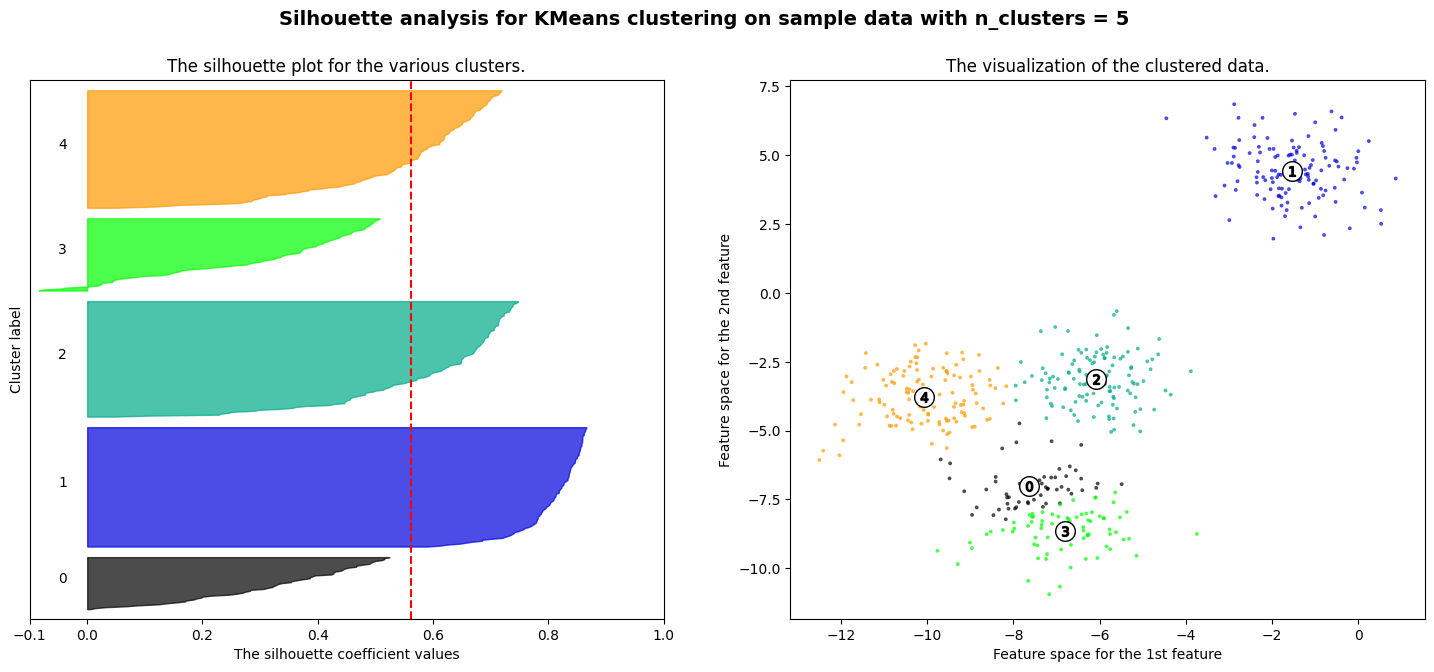

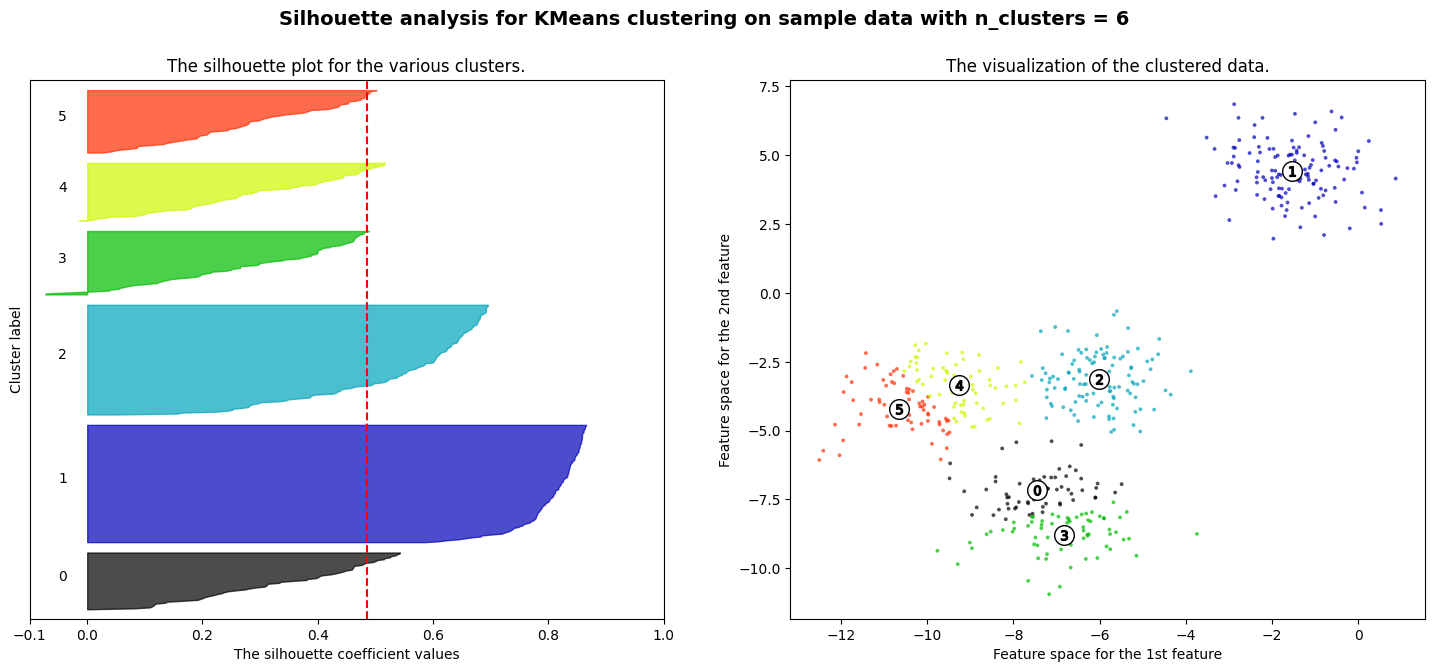

In [ ]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score

# Generating the sample data from make_blobs
# This particular setting has one distinct cluster and 3 clusters placed close
# together.
X, y = make_blobs(
    n_samples=500,
    n_features=2,
    centers=4,
    cluster_std=1,
    center_box=(-10.0, 10.0),
    shuffle=True,
    random_state=1,
)  # For reproducibility

range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()